# Minimal ACLib surrogate validation

This notebook checks archive identity, exact official-wrapper versus custom-wrapper parity, and agreement between archived real runs and the EPM median.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

HERE = next(path for path in [Path.cwd().resolve(), (Path.cwd() / 'experiments/aclib/lpg_zenotravel_surrogate/00_check_bench').resolve()] if (path / 'results/summary.json').is_file())
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))
from minimal_surrogate_validation_analytics import *
summary, parity, agreement = load_validation(HERE)
display(overview_table(summary))

,value
wrapper points,50
wrapper points passed,True
archived comparison points,10000
Spearman PAR10,0.112755
median absolute log10 error,1.506064
within factor 2,0.3011
within factor 5,0.3624
actual timeout/failure fraction,0.7777
predicted timeout fraction,0.1417


## 1. Wrapper parity

Table: maximum differences over 50 identical requests through the official ACLib request-conversion path and the custom in-process benchmark wrapper. Zero differences establish that the experiment calls the installed EPM exactly like the original wrapper core.

In [2]:
display(summary['data_identity'])
display(summary['wrapper_parity'])

{'all_passed': True,
 'archive_conditions': 22,
 'archive_directory': '/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/external/aclib-performance-data/lpg_zenotravel',
 'archive_feature_dimensions': 305,
 'archive_forbiddens': 12,
 'archive_hyperparameters': 67,
 'configspaces_equal': True,
 'feature_dimensions_equal': True,
 'feature_instance_sets_equal': True,
 'packaged_conditions': 22,
 'packaged_feature_dimensions': 305,
 'packaged_forbiddens': 12,
 'packaged_hyperparameters': 67,
 'test_instance_sets_equal': True,
 'training_instance_sets_equal': True}

{'all_passed': True,
 'maximum_cost_absolute_error': 0.0,
 'maximum_input_absolute_error': 0.0,
 'maximum_prediction_absolute_error': 0.0,
 'tested_points': 50}

## 2. Agreement with archived real runs

Scatter plot: archived real PAR10 versus the EPM median for identical configuration–instance pairs; the diagonal denotes equality. Decile-calibration plot: points are sorted by EPM prediction and grouped into ten equal-sized bins, then real and predicted medians are compared. Both axes are logarithmic.

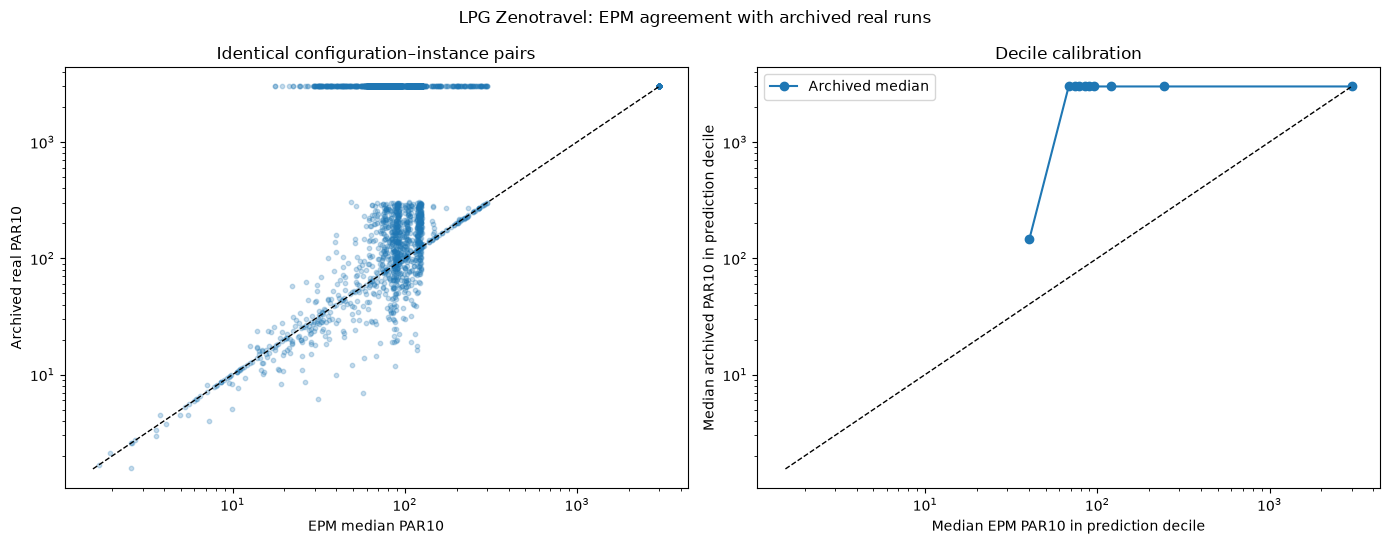

In [3]:
plot_archive_agreement(summary, agreement)
plt.show()

## 3. Error and timeout behaviour

Histogram: absolute log10 error, where the marked thresholds mean factor-two and factor-ten disagreement. Confusion matrix: archived timeout/failure status versus the status produced by applying the installed wrapper's cutoff rule to the EPM median.

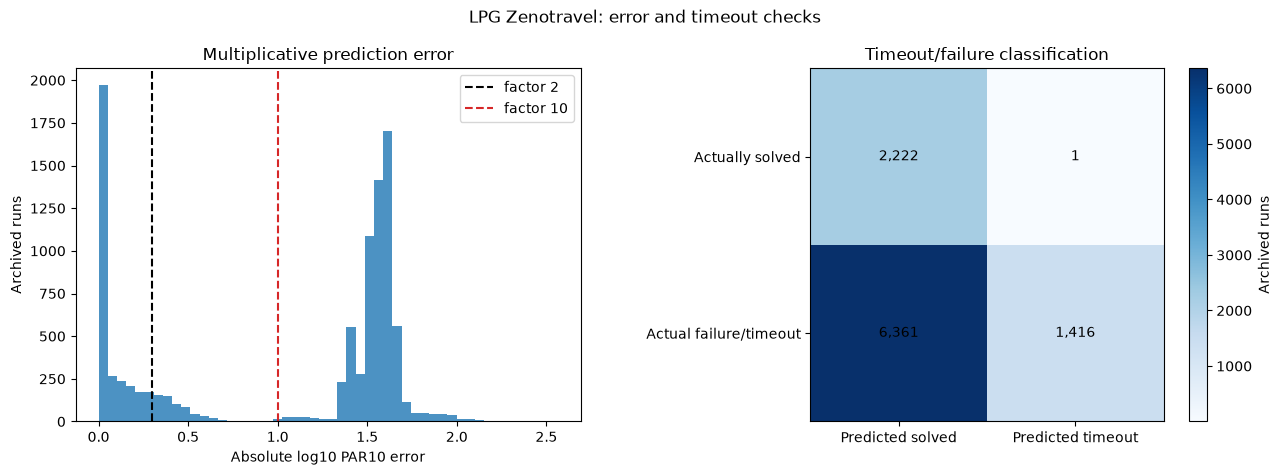

{'actual_par10_quantiles': {'median': 3000.0,
  'q10': 101.5071,
  'q25': 3000.0,
  'q75': 3000.0,
  'q90': 3000.0},
 'actual_timeout_or_failure_fraction': 0.7777,
 'actual_timeouts_with_near_cutoff_prediction_fraction': 0.0,
 'comparison': 'One archived random training run versus the EPM median for the identical configuration-instance pair',
 'fraction_within_factor_10': 0.3639,
 'fraction_within_factor_2': 0.3011,
 'fraction_within_factor_5': 0.3624,
 'mean_absolute_log10_error': 1.0364263608096314,
 'median_absolute_log10_error': 1.5060638501154848,
 'points': 10000,
 'predicted_median_near_cutoff_fraction': 0.0,
 'predicted_median_par10_quantiles': {'median': 86.87923049926758,
  'q10': 62.74552345275879,
  'q25': 73.72321701049805,
  'q75': 119.68151092529297,
  'q90': 3000.0},
 'predicted_timeout_fraction': 0.1417,
 'spearman_log10_par10': 0.11275520125374097,
 'spearman_par10': 0.11275520125374097,
 'timeout_confusion': {'false_negative': 6361,
  'false_positive': 1,
  'precisio

In [4]:
plot_error_and_timeout(summary, agreement)
plt.show()
display(summary['archive_agreement'])

## Interpretation boundary

Each archive row is one real run, whereas the prediction is the conditional EPM median. For stochastic targets, individual disagreement includes target randomness. The archive contributed to EPM construction, so these results test integrity and reproduction rather than independent generalization.